In [1]:
!nvidia-smi

Tue Feb  4 13:31:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install pillow matplotlib

In [3]:
#!pip uninstall tensorflow
#!pip install tensorflow==2.17.0

In [4]:
import tensorflow as tf
print("Tensorflow version: ", tf.version.VERSION)

Tensorflow version:  2.17.0


In [5]:
!apt-cache search libnvinfer

libnvinfer8 - TensorRT runtime libraries
libnvinfer-bin - TensorRT binaries
libnvinfer-plugin8 - TensorRT plugin libraries
libnvinfer-plugin-dev - TensorRT plugin libraries
libnvinfer-samples - TensorRT samples
libnvinfer-dev - TensorRT development libraries
libnvinfer-dispatch8 - TensorRT dispatch runtime library
libnvinfer-dispatch-dev - TensorRT development dispatch runtime libraries
libnvinfer-headers-dev - TensorRT development headers
libnvinfer-headers-plugin-dev - TensorRT plugin headers
libnvinfer-lean8 - TensorRT lean runtime library
libnvinfer-lean-dev - TensorRT lean runtime libraries
libnvinfer-vc-plugin8 - TensorRT vc-plugin library
libnvinfer-vc-plugin-dev - TensorRT vc-plugin library
python3-libnvinfer - Python 3 bindings for TensorRT standard runtime
python3-libnvinfer-dev - Python 3 development package for TensorRT standard runtime
python3-libnvinfer-dispatch - Python 3 bindings for TensorRT dispatch runtime
python3-libnvinfer-lean - Python 3 bindings for TensorRT lean

In [6]:
!sudo apt-get update
!sudo apt-get install -y libnvinfer8 libnvinfer-plugin8

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

In [7]:
!dpkg -l | grep nvinfer

ii  libnvinfer-plugin8                     8.6.1.6-1+cuda12.0                      amd64        TensorRT plugin libraries
ii  libnvinfer8                            8.6.1.6-1+cuda12.0                      amd64        TensorRT runtime libraries


In [8]:
from tensorflow.python.client import device_lib

def check_tensor_core_gpu_present():
    local_device_protos = device_lib.list_local_devices()
    for line in local_device_protos:
        if "compute capability" in str(line):
            compute_capability = float(line.physical_device_desc.split("compute capability: ")[-1])
            if compute_capability>=7.0:
                return True

print("Tensor Core GPU Present:", check_tensor_core_gpu_present())
tensor_core_gpu = check_tensor_core_gpu_present()

Tensor Core GPU Present: True


In [9]:
from __future__ import absolute_import, division, print_function, unicode_literals
import os
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.python.compiler.tensorrt import trt_convert as trt
from tensorflow.python.saved_model import tag_constants
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

In [10]:
!mkdir ./data
!wget  -O ./data/img0.JPG "https://d17fnq9dkz9hgj.cloudfront.net/breed-uploads/2018/08/siberian-husky-detail.jpg?bust=1535566590&width=630"
!wget  -O ./data/img1.JPG "https://www.hakaimagazine.com/wp-content/uploads/header-gulf-birds.jpg"
#!wget  -O ./data/img2.JPG "https://www.artis.nl/media/filer_public_thumbnails/filer_public/00/f1/00f1b6db-fbed-4fef-9ab0-84e944ff11f8/chimpansee_amber_r_1920x1080.jpg__1920x1080_q85_subject_location-923%2C365_subsampling-2.jpg"
!wget  -O ./data/img2.JPG "https://www.familyhandyman.com/wp-content/uploads/2018/09/How-to-Avoid-Snakes-Slithering-Up-Your-Toilet-shutterstock_780480850.jpg"

mkdir: cannot create directory ‘./data’: File exists
--2025-02-04 13:31:49--  https://d17fnq9dkz9hgj.cloudfront.net/breed-uploads/2018/08/siberian-husky-detail.jpg?bust=1535566590&width=630
Resolving d17fnq9dkz9hgj.cloudfront.net (d17fnq9dkz9hgj.cloudfront.net)... 3.163.128.12, 3.163.128.2, 3.163.128.5, ...
Connecting to d17fnq9dkz9hgj.cloudfront.net (d17fnq9dkz9hgj.cloudfront.net)|3.163.128.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24112 (24K) [image/jpeg]
Saving to: ‘./data/img0.JPG’

./data/img0.JPG     100%[===================>]  23.55K  --.-KB/s    in 0.001s  

2025-02-04 13:31:49 (20.0 MB/s) - ‘./data/img0.JPG’ saved [24112/24112]

--2025-02-04 13:31:49--  https://www.hakaimagazine.com/wp-content/uploads/header-gulf-birds.jpg
Resolving www.hakaimagazine.com (www.hakaimagazine.com)... 164.92.73.117
Connecting to www.hakaimagazine.com (www.hakaimagazine.com)|164.92.73.117|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45

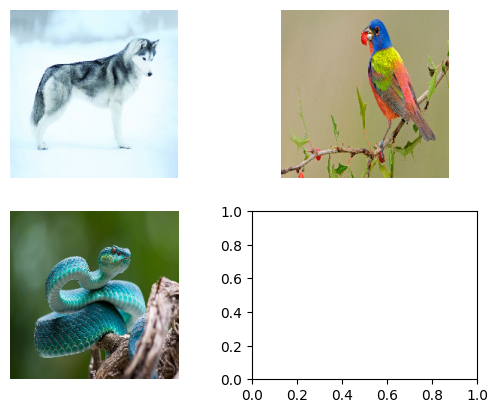

In [11]:
from tensorflow.keras.preprocessing import image

fig, axes = plt.subplots(nrows=2, ncols=2)

for i in range(3):
  img_path = './data/img%d.JPG'%i
  img = image.load_img(img_path, target_size=(224, 224))
  plt.subplot(2,2,i+1)
  plt.imshow(img);
  plt.axis('off');

In [12]:
model = ResNet50(weights='imagenet')

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
./data/img0.JPG - Predicted: [('n02110185', 'Siberian_husky', 0.5568134), ('n02109961', 'Eskimo_dog', 0.41662613), ('n02110063', 'malamute', 0.021314166)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
./data/img1.JPG - Predicted: [('n01820546', 'lorikeet', 0.30117285), ('n01537544', 'indigo_bunting', 0.16982141), ('n01828970', 'bee_eater', 0.16135603)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
./data/img2.JPG - Predicted: [('n01729977', 'green_snake', 0.41348848), ('n03627232', 'knot', 0.10407336), ('n01749939', 'green_mamba', 0.06852533)]


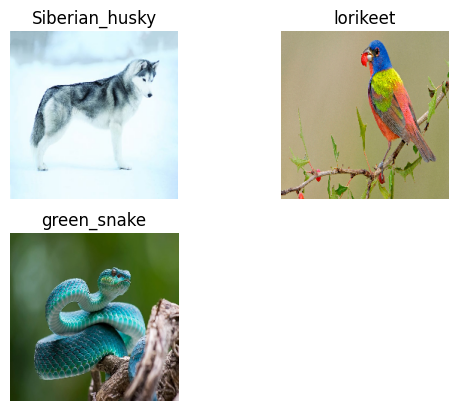

In [13]:
for i in range(3):
  img_path = './data/img%d.JPG'%i
  img = image.load_img(img_path, target_size=(224, 224))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = preprocess_input(x)

  preds = model.predict(x)
  # decode the results into a list of tuples (class, description, probability)
  # (one such list for each sample in the batch)
  print('{} - Predicted: {}'.format(img_path, decode_predictions(preds, top=3)[0]))

  plt.subplot(2,2,i+1)
  plt.imshow(img);
  plt.axis('off');
  plt.title(decode_predictions(preds, top=3)[0][0][1])


In [14]:
# Save the entire model as a SavedModel.
model.export('resnet50_saved_model')

Saved artifact at 'resnet50_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Captures:
  136262133787408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136258444079568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136258443821328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136258443822288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136262133790672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136262133786064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136258443824976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136258443826512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136258443827472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136258443825168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1362584

In [15]:
!saved_model_cli show --all --dir resnet50_saved_model

2025-02-04 13:32:11.550958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-04 13:32:11.568904: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-04 13:32:11.574397: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1738675934.966948   13337 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1738675934.976920   13337 cuda_executor.cc:1015] succ

In [16]:
model = tf.saved_model.load('resnet50_saved_model')

In [17]:
infer = model.signatures['serving_default']
print(infer)

ConcreteFunction Input Parameters:
  keras_tensor (KEYWORD_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  Dict[['output_0', TensorSpec(shape=(None, 1000), dtype=tf.float32, name='output_0')]]
Captures:
  136256819922704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819922512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819921936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819921744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819922320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819922128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819921552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819921360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819855184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819854992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136256819921168: TensorSpec(shape=(), dtype=

In [18]:
batch_size = 8
batched_input = np.zeros((batch_size, 224, 224, 3), dtype=np.float32)

for i in range(batch_size):
  img_path = './data/img%d.JPG' % (i % 3)
  img = image.load_img(img_path, target_size=(224, 224))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = preprocess_input(x)
  batched_input[i, :] = x
batched_input = tf.constant(batched_input)
print('batched_input shape: ', batched_input.shape)

batched_input shape:  (8, 224, 224, 3)


In [19]:
# Benchmarking throughput
N_warmup_run = 50
N_run = 1000
elapsed_time = []

for i in range(N_warmup_run):
  preds = infer(batched_input)

for i in range(N_run):
  start_time = time.time()
  preds = infer(batched_input)
  end_time = time.time()
  elapsed_time = np.append(elapsed_time, end_time - start_time)
  if i % 50 == 0:
    print('Step {}: {:4.1f}ms'.format(i, (elapsed_time[-50:].mean()) * 1000))

print('Throughput: {:.0f} images/s'.format(N_run * batch_size / elapsed_time.sum()))

Step 0: 32.6ms
Step 50: 33.5ms
Step 100: 33.5ms
Step 150: 33.6ms
Step 200: 33.6ms
Step 250: 33.8ms
Step 300: 33.9ms
Step 350: 34.0ms
Step 400: 34.1ms
Step 450: 34.2ms
Step 500: 34.3ms
Step 550: 34.4ms
Step 600: 34.5ms
Step 650: 34.6ms
Step 700: 34.7ms
Step 750: 34.8ms
Step 800: 35.0ms
Step 850: 35.0ms
Step 900: 35.1ms
Step 950: 45.6ms
Throughput: 230 images/s


#TF-TRT FP32 model

In [20]:
print('Converting to TF-TRT FP32...')

converter = trt.TrtGraphConverterV2(input_saved_model_dir='resnet50_saved_model',
                                   precision_mode=trt.TrtPrecisionMode.FP32,
                                    max_workspace_size_bytes=8000000000)
converter.convert()
converter.save(output_saved_model_dir='resnet50_saved_model_TFTRT_FP32')
print('Done Converting to TF-TRT FP32')

Converting to TF-TRT FP32...
Done Converting to TF-TRT FP32


In [21]:
!saved_model_cli show --all --dir resnet50_saved_model_TFTRT_FP32

2025-02-04 13:33:12.553029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-04 13:33:12.570988: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-04 13:33:12.576333: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1738675995.982303   13642 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1738675995.992746   13642 cuda_executor.cc:1015] succ

In [22]:
def predict_tftrt(input_saved_model):
    """Runs prediction on a single image and shows the result.
    input_saved_model (string): Name of the input model stored in the current dir
    """
    img_path = './data/img0.JPG'  # Siberian_husky
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    x = tf.constant(x)

    saved_model_loaded = tf.saved_model.load(input_saved_model, tags=[tag_constants.SERVING])
    signature_keys = list(saved_model_loaded.signatures.keys())
    print(signature_keys)

    infer = saved_model_loaded.signatures['serving_default']
    print(infer.structured_outputs)

    labeling = infer(x)
    preds = labeling['output_0'].numpy()
    print('{} - Predicted: {}'.format(img_path, decode_predictions(preds, top=3)[0]))
    plt.subplot(2,2,1)
    plt.imshow(img);
    plt.axis('off');
    plt.title(decode_predictions(preds, top=3)[0][0][1])

In [23]:
def benchmark_tftrt(input_saved_model):
    saved_model_loaded = tf.saved_model.load(input_saved_model, tags=[tag_constants.SERVING])
    infer = saved_model_loaded.signatures['serving_default']

    N_warmup_run = 50
    N_run = 1000
    elapsed_time = []

    for i in range(N_warmup_run):
      labeling = infer(batched_input)

    for i in range(N_run):
      start_time = time.time()
      labeling = infer(batched_input)
      end_time = time.time()
      elapsed_time = np.append(elapsed_time, end_time - start_time)
      if i % 50 == 0:
        print('Step {}: {:4.1f}ms'.format(i, (elapsed_time[-50:].mean()) * 1000))

    print('Throughput: {:.0f} images/s'.format(N_run * batch_size / elapsed_time.sum()))

['serving_default']
{'output_0': TensorSpec(shape=(None, 1000), dtype=tf.float32, name='output_0')}
./data/img0.JPG - Predicted: [('n02110185', 'Siberian_husky', 0.55681354), ('n02109961', 'Eskimo_dog', 0.41662621), ('n02110063', 'malamute', 0.021314066)]


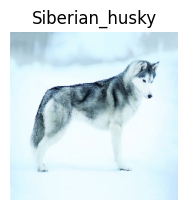

In [24]:
predict_tftrt('resnet50_saved_model_TFTRT_FP32')

In [25]:
benchmark_tftrt('resnet50_saved_model_TFTRT_FP32')

Step 0: 18.1ms
Step 50: 18.7ms
Step 100: 18.7ms
Step 150: 18.6ms
Step 200: 18.6ms
Step 250: 18.5ms
Step 300: 18.6ms
Step 350: 18.5ms
Step 400: 18.5ms
Step 450: 18.3ms
Step 500: 18.3ms
Step 550: 18.3ms
Step 600: 18.2ms
Step 650: 18.1ms
Step 700: 18.1ms
Step 750: 18.0ms
Step 800: 18.1ms
Step 850: 18.0ms
Step 900: 18.0ms
Step 950: 18.0ms
Throughput: 437 images/s


# TF-TRT FP16 model

In [26]:
print('Converting to TF-TRT FP16...')

converter = trt.TrtGraphConverterV2(input_saved_model_dir='resnet50_saved_model',
                                   precision_mode=trt.TrtPrecisionMode.FP16,
                                    max_workspace_size_bytes=8000000000)
converter.convert()
converter.save(output_saved_model_dir='resnet50_saved_model_TFTRT_FP16')
print('Done Converting to TF-TRT FP16')

Converting to TF-TRT FP16...
Done Converting to TF-TRT FP16


['serving_default']
{'output_0': TensorSpec(shape=(None, 1000), dtype=tf.float32, name='output_0')}
./data/img0.JPG - Predicted: [('n02110185', 'Siberian_husky', 0.55810547), ('n02109961', 'Eskimo_dog', 0.41503906), ('n02110063', 'malamute', 0.021484375)]


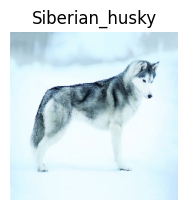

In [27]:
predict_tftrt('resnet50_saved_model_TFTRT_FP16')

In [28]:
benchmark_tftrt('resnet50_saved_model_TFTRT_FP16')

Step 0:  6.8ms
Step 50:  6.6ms
Step 100:  6.3ms
Step 150:  6.3ms
Step 200:  6.8ms
Step 250:  6.5ms
Step 300:  6.7ms
Step 350:  7.4ms
Step 400:  4.6ms
Step 450:  4.1ms
Step 500:  4.8ms
Step 550:  4.8ms
Step 600:  4.7ms
Step 650:  4.7ms
Step 700:  4.8ms
Step 750:  4.8ms
Step 800:  4.7ms
Step 850:  4.8ms
Step 900:  4.7ms
Step 950:  4.8ms
Throughput: 1484 images/s


# TF-TRT INT8 model

In [29]:
#import os
#os.kill(os.getpid(), 9)

In [30]:
from __future__ import absolute_import, division, print_function, unicode_literals
import os
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.python.compiler.tensorrt import trt_convert as trt
from tensorflow.python.saved_model import tag_constants
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

In [31]:
batch_size = 8
batched_input = np.zeros((batch_size, 224, 224, 3), dtype=np.float32)

for i in range(batch_size):
  img_path = './data/img%d.JPG' % (i % 3)
  img = image.load_img(img_path, target_size=(224, 224))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = preprocess_input(x)
  batched_input[i, :] = x
batched_input = tf.constant(batched_input)
print('batched_input shape: ', batched_input.shape)

batched_input shape:  (8, 224, 224, 3)


In [32]:
def calibration_input_fn():
    yield (batched_input, )

print('Converting to TF-TRT INT8...')

converter = trt.TrtGraphConverterV2(input_saved_model_dir='resnet50_saved_model',
                                   precision_mode=trt.TrtPrecisionMode.INT8,
                                    max_workspace_size_bytes=8000000000)

converter.convert(calibration_input_fn=calibration_input_fn)
converter.save(output_saved_model_dir='resnet50_saved_model_TFTRT_INT8')
print('Done Converting to TF-TRT INT8')

Converting to TF-TRT INT8...
Done Converting to TF-TRT INT8


In [33]:
def predict_tftrt(input_saved_model):
    """Runs prediction on a single image and shows the result.
    input_saved_model (string): Name of the input model stored in the current dir
    """
    img_path = './data/img0.JPG'  # Siberian_husky
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    x = tf.constant(x)

    saved_model_loaded = tf.saved_model.load(input_saved_model, tags=[tag_constants.SERVING])
    signature_keys = list(saved_model_loaded.signatures.keys())
    print(signature_keys)

    infer = saved_model_loaded.signatures['serving_default']
    print(infer.structured_outputs)

    labeling = infer(x)
    preds = labeling['output_0'].numpy()
    print('{} - Predicted: {}'.format(img_path, decode_predictions(preds, top=3)[0]))
    plt.subplot(2,2,1)
    plt.imshow(img);
    plt.axis('off');
    plt.title(decode_predictions(preds, top=3)[0][0][1])

In [34]:
def benchmark_tftrt(input_saved_model):
    saved_model_loaded = tf.saved_model.load(input_saved_model, tags=[tag_constants.SERVING])
    infer = saved_model_loaded.signatures['serving_default']

    N_warmup_run = 50
    N_run = 1000
    elapsed_time = []

    for i in range(N_warmup_run):
      labeling = infer(batched_input)

    for i in range(N_run):
      start_time = time.time()
      labeling = infer(batched_input)
      #prob = labeling['probs'].numpy()
      end_time = time.time()
      elapsed_time = np.append(elapsed_time, end_time - start_time)
      if i % 50 == 0:
        print('Step {}: {:4.1f}ms'.format(i, (elapsed_time[-50:].mean()) * 1000))

    print('Throughput: {:.0f} images/s'.format(N_run * batch_size / elapsed_time.sum()))

['serving_default']
{'output_0': TensorSpec(shape=(None, 1000), dtype=tf.float32, name='output_0')}
./data/img0.JPG - Predicted: [('n02110185', 'Siberian_husky', 0.5678711), ('n02109961', 'Eskimo_dog', 0.40893555), ('n02110063', 'malamute', 0.019729614)]


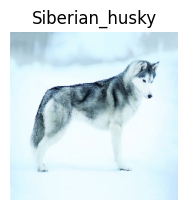

In [35]:
predict_tftrt('resnet50_saved_model_TFTRT_INT8')

In [36]:
benchmark_tftrt('resnet50_saved_model_TFTRT_INT8')

Step 0:  3.7ms
Step 50:  3.8ms
Step 100:  3.9ms
Step 150:  3.9ms
Step 200:  4.0ms
Step 250:  4.0ms
Step 300:  4.6ms
Step 350:  3.9ms
Step 400:  4.0ms
Step 450: 11.5ms
Step 500:  3.9ms
Step 550:  4.0ms
Step 600:  4.1ms
Step 650:  4.3ms
Step 700:  3.9ms
Step 750:  3.9ms
Step 800:  4.0ms
Step 850:  3.8ms
Step 900:  4.2ms
Step 950:  4.0ms
Throughput: 1823 images/s
